# 1. Environment Setup

In [1]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'matplotlib': 'matplotlib',
    'requests': 'requests',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 



Installation complete. 



In [2]:
import os
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 2. Configuration

In [3]:
DIR = "../data"

SAMPLED_PARQUET= os.path.join(DIR, "processed/amazon_reviews_s10.parquet")
MULTIMODAL_PARQUET = os.path.join(DIR, "processed/multimodal_s10.parquet")
IMAGE_DIR = os.path.join(DIR, "images")

os.makedirs(IMAGE_DIR, exist_ok=True)

# 3. Load the dataset

In [4]:
df = pd.read_parquet(SAMPLED_PARQUET)

if "image_bucket" not in df.columns and "image_count" in df.columns:
    df["image_bucket"] = pd.cut(
        df["image_count"].fillna(0),
        bins=[-1, 0, 1, 2, np.inf],
        labels=[0, 1, 2, 3],
        ordered=True,
    ).astype("int8")

print("Dataset size:", len(df))

Dataset size: 942176


## 3.1. Dataset Preview

In [5]:
df.head()

,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity,image_bucket
0,5,[],B0051VVOB2,2012-01-28 13:35:06.000,3,Kindle Fire Initially I had trouble using the ...,1832,1,0,False,5548,13072,0
1,5,[],B010BWYDYA,2008-11-26 16:11:05.000,2,I'm amazed This is my first experience with an...,445,1,0,False,4390,16910,0
2,5,[],B0051VVOB2,2011-12-25 19:15:13.000,4,Fabulous!! I absolutely Love the Kindle Fire. ...,701,1,0,False,5515,13072,0
3,5,[],B0791TX5P5,2019-09-18 17:01:20.700,2,Great but not without flaws and quirks. I don’...,1193,1,0,False,8339,10077,0
4,1,[],B075X8471B,2017-01-25 22:45:43.000,3,Dose not work with Echo Dot....... This item w...,283,1,0,False,7373,9195,0


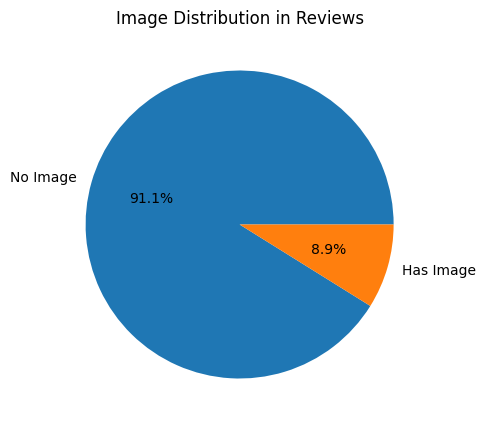


📸 Image Distribution:
  Has Image: 83,577 reviews (8.9%)
  No Image: 858,599 reviews (91.1%)


In [6]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

In [7]:
# Debug: Check the structure of images data
print("Sample image data:")
for i in range(25, 28):
    print(f"\nRow {i}:")
    print(f"  Type: {type(df['images'].iloc[i])}")
    print(f"  Value: {df['images'].iloc[i]}")
    if isinstance(df['images'].iloc[i], list) and len(df['images'].iloc[i]) > 0:
        print(f"  First item type: {type(df['images'].iloc[i][0])}")
        print(f"  First item: {df['images'].iloc[i][0]}")

Sample image data:

Row 25:
  Type: <class 'numpy.ndarray'>
  Value: []

Row 26:
  Type: <class 'numpy.ndarray'>
  Value: []

Row 27:
  Type: <class 'numpy.ndarray'>
  Value: []


# 4. Extract Image Outline

In [8]:
def extract_first_image_url(images_column):

    if isinstance(images_column, np.ndarray):
        images_column = images_column.tolist()

    # Empty list
    if len(images_column) == 0:
        return None

    first = images_column[0]

    # Priority selection
    return (
        first.get("large_image_url")
        or first.get("medium_image_url")
        or first.get("small_image_url")
    )

## 4.1. Create URL column

In [9]:
df["image_url"] = df["images"].apply(extract_first_image_url)

print("Images available:", df["image_url"].notna().sum())

Images available: 83577


In [10]:
df.iloc[19:23][["images", "image_url"]]

,images,image_url
19,[],NaN
20,[],NaN
21,[],NaN
22,[],NaN


# 5. Download Image

In [11]:
def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            # print(f"HTTP Error {response.status_code}: {url}")
            return False

        image = Image.open(BytesIO(response.content))
        image.verify()  # validate image

        with open(save_path, "wb") as f:
            f.write(response.content)

        return True

    except requests.exceptions.Timeout:
        print(f"Timeout: {url}")
        return False
    except requests.exceptions.ConnectionError:
        print(f"Connection Error: {url}")
        return False
    except Exception as e:
        print(f"Error: {type(e).__name__} - {url}")
        return False

## 5.1. Download Loop

In [12]:
success = 0
failed = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    url = row["image_url"]

    if pd.isna(url):
        continue

    filename = f"{idx}.jpg"
    save_path = os.path.join(IMAGE_DIR, filename)

    # Skip already downloaded images
    if os.path.exists(save_path):
        success += 1
        continue

    ok = download_image(url, save_path)

    if ok:
        success += 1
    else:
        failed += 1

print(f"\n\nDownloaded: {success}")
print(f"Failed: {failed}")

  0%|          | 0/942176 [00:00<?, ?it/s]

  0%|          | 1/942176 [00:02<587:57:12,  2.25s/it]

  0%|          | 3831/942176 [00:02<06:52, 2275.54it/s]

  1%|          | 7821/942176 [00:02<03:00, 5177.53it/s]

  1%|▏         | 11944/942176 [00:02<01:47, 8681.10it/s]

...

 99%|█████████▉| 932992/942176 [04:46<00:01, 8308.49it/s] 

 99%|█████████▉| 936240/942176 [04:46<00:00, 10729.19it/s]

100%|█████████▉| 939523/942176 [04:46<00:00, 13533.27it/s]

100%|██████████| 942176/942176 [04:46<00:00, 3286.37it/s] 



Downloaded: 83061
Failed: 516


# 6. Save Image Mapping

In [13]:
def get_path(i):   
    p = os.path.join(IMAGE_DIR, f"{i}.jpg")
    return p if os.path.exists(p) else None

df["image_path"] = df.index.map(get_path)

In [14]:
df.iloc[13:17][["image_url", "image_path", "image_bucket"]]

,image_url,image_path,image_bucket
13,NaN,NaN,0
14,NaN,NaN,0
15,NaN,NaN,0
16,NaN,NaN,0


# 7. Drop redundant features

In [15]:
drop_cols = ["images", "image_url"]
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

In [16]:
print(f"Dataset shape: {df.shape[0]:2,} rows x {df.shape[1]} columns")

print(f"\nDataset Columns with dtypes: \n{df.dtypes}")

Dataset shape: 942,176 rows x 13 columns

Dataset Columns with dtypes: 
rating                               int8
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
days_since_first_review             int32
product_popularity                  int32
image_bucket                         int8
image_path                            str
dtype: object


In [17]:
df.to_parquet(MULTIMODAL_PARQUET, index=False)

print("Dataset updated with image paths.")

Dataset updated with image paths.
